# Length scale bounds

Sigurd Carlsen, September 2019.
Søren Bertelsen, (minor changes) December 2024.

To use different length scale bounds we need to pass the optional paramter acq_optimizer_kwargs =  to the optimize.

This parameter is a dict containing optional parameters for the optimizer. An example:
`acq_optimizer_kwargs = {
"length_scale_bounds":[(0.1,1),(0.5,1.5)],
"length_scale":[1.0,3.0]
}`

For a 2-dimensional problem the length_scale_bounds must be a list of length 2 containing lower and upper bounds as tuples.
length_scale is a list of numbers defining the length scale for each dimension.


Lenght scale and length scale bound can only be used when base estimator is set to "GP".
Length scale bounds are only used for the Matern kernel i.e when at least one of the dimensions is non-categorical.

In [1]:
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.set_cmap("viridis")

from ProcessOptimizer import Optimizer

<Figure size 640x480 with 0 Axes>

In [2]:
acq_optimizer_kwargs = {"length_scale_bounds" :[(0.01,0.01)]}

In [3]:
opt = Optimizer([(-2.0, 2.0)], "GP", n_initial_points = 5, lhs=False, acq_optimizer="sampling",acq_optimizer_kwargs=acq_optimizer_kwargs, random_state=42)

In [4]:

noise_level = 0.1

# Our 1D toy problem, this is the function we are trying to
# minimize
def objective(x, noise_level=noise_level):
    return np.sin(5 * x[0]) * (1 - np.tanh(x[0] ** 2)) + np.random.randn() * noise_level

In [5]:
x = np.linspace(-2, 2, 400).reshape(-1, 1)
fx = np.array([objective(x_i, noise_level=0.0) for x_i in x])

In [6]:
from ProcessOptimizer.acquisition import gaussian_ei

def plot_optimizer(opt, x, fx):
    model = opt.models[-1]
    x_model = opt.space.transform(x.tolist())

    # Plot true function.
    plt.plot(x, fx, "r--", label="True (unknown)")
    plt.fill(np.concatenate([x, x[::-1]]),
             np.concatenate([fx - 1.9600 * noise_level, 
                             fx[::-1] + 1.9600 * noise_level]),
             alpha=.2, fc="r", ec="None")

    # Plot Model(x) + contours
    y_pred, sigma = model.predict(x_model, return_std=True)
    plt.plot(x, y_pred, "g--", label=r"$\mu(x)$")
    plt.fill(np.concatenate([x, x[::-1]]),
             np.concatenate([y_pred - 1.9600 * sigma, 
                             (y_pred + 1.9600 * sigma)[::-1]]),
             alpha=.2, fc="g", ec="None")

    # Plot sampled points
    plt.plot(opt.Xi, opt.yi,
             "r.", markersize=8, label="Observations")

    acq = gaussian_ei(x_model, model, y_opt=np.min(opt.yi))
    # shift down to make a better plot
    acq = 4*acq - 2
    plt.plot(x, acq, "b", label="EI(x)")
    plt.fill_between(x.ravel(), -2.0, acq.ravel(), alpha=0.3, color='blue')
    
    # Adjust plot layout
    plt.grid()
    plt.legend(loc='best')


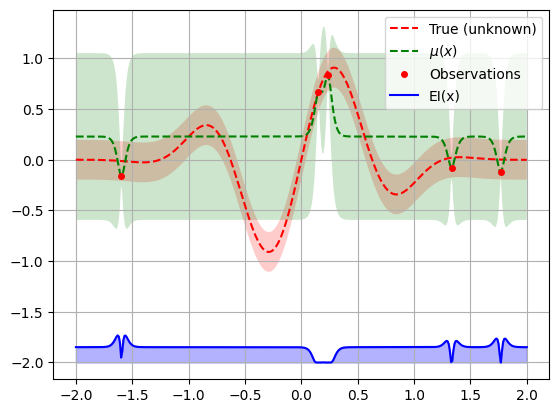

In [7]:
for i in range(5):
    next_x = opt.ask()
    f_val = objective(next_x)
    opt.tell(next_x, f_val)
plot_optimizer(opt, x, fx)

Let's change the length scale bounds to see how it affects the surrogate function.

In [8]:
acq_optimizer_kwargs = {"length_scale_bounds" :[(0.1,1.0)]}

In [9]:
opt = Optimizer([(-2.0, 2.0)], "GP", n_initial_points = 5, lhs=False, acq_optimizer="sampling",acq_optimizer_kwargs=acq_optimizer_kwargs, random_state=42)

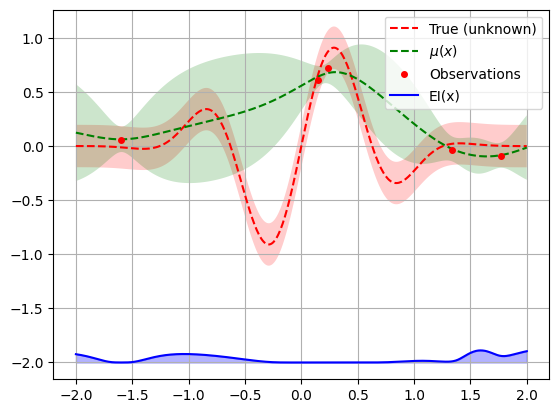

In [10]:
for i in range(5):
    next_x = opt.ask()
    f_val = objective(next_x)
    a = opt.tell(next_x, f_val)
    
plot_optimizer(opt, x, fx)